<a href="https://colab.research.google.com/github/AkemjotSingh/csot-ml-astronomy-akemjotsingh/blob/main/week1_data_starter_akemjotsingh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSoT'26 — ML in Astronomy — Week 1 · Part 2: Data Pipeline (Starter)

**Goal:** Get the Galaxy Zoo 2 images flowing through a PyTorch data pipeline and *look at them*.

By the end you'll join the official morphology labels to flat image files, build an `ImageFolder`-ready layout, create a `DataLoader` yielding `(32, 3, 64, 64)` batches, and plot a matplotlib grid of real galaxies.

**Before you begin:**
1. Finish **Part 1** (`week1_starter.ipynb`) first.
2. Switch this notebook to a **GPU runtime** (`Runtime → Change runtime type → GPU`). Not strictly required for data loading, but keeps you consistent.
3. Read [`08-data-pipelines.md`](../08-data-pipelines.md) — every TODO below maps to a section there.

> **Heads-up:** The [Kaggle Galaxy Zoo 2 download](https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images) does **not** ship class subfolders. Images are named `{asset_id}.jpg` in a flat folder; labels live in CSV catalogues. We join them first, then use `ImageFolder`.

Attempt every TODO before opening `week1_data_solution.ipynb`.

## Step 0 — Imports

In [ ]:
import os
import random
from pathlib import Path

import pandas as pd
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
import torchvision
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


## Step 1 — Get the dataset into Colab

The Kaggle bundle contains:
- `images_gz2.zip` — ~243k JPGs named `1.jpg`, `2.jpg`, … (no class folders)
- `gz2_filename_mapping.csv` — maps each `asset_id` to an SDSS `objid`

Morphology labels come separately from the official GZ2 catalogue ([Hart et al. 2016](https://data.galaxyzoo.org/)), which we download as `gz2_hart16.csv.gz`.

**Option A — Kaggle API (recommended).** Upload your `kaggle.json` token, then run the download/unzip commands in the solution notebook (or adapt the cell below).

Fill in the cell below to download/locate the data and set the paths.

In [ ]:
from google.colab import files

files.upload()

os.makedirs("/root/.config/kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.config/kaggle/kaggle.json")
os.chmod("/root/.config/kaggle/kaggle.json", 0o600)

!pip install kaggle -q
!kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images
!unzip -q galaxy-zoo-2-images.zip -d galaxy_raw

!wget -q "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz" -O galaxy_raw/gz2_hart16.csv.gz
!gunzip galaxy_raw/gz2_hart16.csv.gz

RAW_ROOT   = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2" / "images"
DATA_ROOT  = Path("galaxy_data")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.06G/3.06G [00:26<00:00, 124MB/s] 



## Step 2 — Inspect the raw layout

List what's inside `RAW_ROOT` and peek at `IMAGES_DIR`. You should see a CSV mapping file and many JPGs named by integer ID — **not** morphology subfolders.

Also open `gz2_filename_mapping.csv` and confirm columns `objid`, `sample`, `asset_id`.

In [ ]:
print("RAW_ROOT contents:", sorted(p.name for p in RAW_ROOT.iterdir()))
jpg_count = sum(1 for _ in IMAGES_DIR.glob("*.jpg"))
print(f"Flat JPG count in {IMAGES_DIR}: {jpg_count:,}")

mapping_head = pd.read_csv(RAW_ROOT / "gz2_filename_mapping.csv", nrows=3)
print(mapping_head)

RAW_ROOT contents: ['gz2_filename_mapping.csv', 'gz2_hart16.csv', 'images_gz2']
Flat JPG count in galaxy_raw/images_gz2/images: 243,434
                objid    sample  asset_id
0  587722981736120347  original         1
1  587722981736579107  original         2
2  587722981741363294  original         3


## Step 3 — Join labels and build an ImageFolder layout

`ImageFolder` expects `root/<class_name>/<image>.jpg`. Our Kaggle download doesn't provide that, so we:

1. Merge `gz2_filename_mapping.csv` with `gz2_hart16.csv` on `objid`.
2. Collapse the detailed `gz2_class` string (e.g. `Sc2t`, `Ei`) into a few high-level buckets.
3. Symlink a **balanced subset** into `DATA_ROOT/<class>/` so Colab stays fast.

Implement `high_level_label(gz2_class)` and `build_imagefolder_layout(...)` — see [`08-data-pipelines.md`](../08-data-pipelines.md).

In [ ]:
def high_level_label(gz2_class: str):
    """Collapse detailed GZ2 morphology codes to a few training buckets."""
    if not gz2_class or gz2_class == "A":
        return None  # artifact / ambiguous — skip
    if gz2_class.startswith("E"):
        return "elliptical"
    if gz2_class.startswith("SB"):
        return "spiral_barred"
    if gz2_class.startswith("S"):
        return "spiral"
    return None


def build_imagefolder_layout(
    images_dir,
    mapping_csv,
    labels_csv,
    out_root,
    per_class=200,
    seed=42,
):
    """Symlink a balanced subset into out_root/<class>/ for ImageFolder."""
    mapping = pd.read_csv(mapping_csv)
    labels = pd.read_csv(labels_csv).rename(columns={"dr7objid": "objid"})
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    df["label"] = df["gz2_class"].map(high_level_label)
    df = df.dropna(subset=["label"])

    images_dir = Path(images_dir)
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    counts = {}
    for label in sorted(df["label"].unique()):
        class_dir = out_root / label
        class_dir.mkdir(exist_ok=True)
        rows = df[df["label"] == label]
        if len(rows) > per_class:
            rows = rows.sample(n=per_class, random_state=seed)
        linked = 0
        for _, row in rows.iterrows():
            src = images_dir / f"{int(row.asset_id)}.jpg"
            dst = class_dir / f"{int(row.asset_id)}.jpg"
            if src.exists() and not dst.exists():
                os.symlink(src.resolve(), dst)
                linked += 1
        counts[label] = linked
    return counts

PER_CLASS = 200  # balanced subset — fast on Colab; increase once the pipeline works
counts = build_imagefolder_layout(
    IMAGES_DIR,
    RAW_ROOT / "gz2_filename_mapping.csv",
    RAW_ROOT / "gz2_hart16.csv",
    DATA_ROOT,
    per_class=PER_CLASS,
)
print("Symlinked per class:", counts)
print("DATA_ROOT classes:", sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir()))

Symlinked per class: {'elliptical': 200, 'spiral': 200, 'spiral_barred': 200}
DATA_ROOT classes: ['elliptical', 'spiral', 'spiral_barred']


## Step 4 — Build the transforms pipeline

Compose: `Resize((64, 64))` → `ToTensor()` → `Normalize([0.5]*3, [0.5]*3)`.
See [`08-data-pipelines.md`](../08-data-pipelines.md) for why each step exists and why order matters.

In [ ]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

## Step 5 — Wrap it in an ImageFolder

Create `dataset = ImageFolder(root=DATA_ROOT, transform=transform)`. Print `len(dataset)`, `dataset.classes`, and `dataset.class_to_idx`.

*Remember:* classes are assigned **alphabetically** — and only exist because we created the subfolders in Step 3.

In [ ]:
dataset = ImageFolder(root=DATA_ROOT, transform=transform)
print("num images   :", len(dataset))
print("classes      :", dataset.classes)
print("class_to_idx :", dataset.class_to_idx)

num images   : 600
classes      : ['elliptical', 'spiral', 'spiral_barred']
class_to_idx : {'elliptical': 0, 'spiral': 1, 'spiral_barred': 2}


## Step 6 — Fetch a single sample

In [ ]:
image, label = dataset[0]
print("shape :", image.shape)   # torch.Size([3, 64, 64])
print("dtype :", image.dtype)   # torch.float32
print("label :", label, "->", dataset.classes[label])

shape : torch.Size([3, 64, 64])
dtype : torch.float32
label : 0 -> elliptical


## Step 7 — Build a DataLoader and peek at one batch

In [ ]:
loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)

images, labels = next(iter(loader))
print("images:", images.shape)
print("labels:", labels.shape)

images: torch.Size([32, 3, 64, 64])
labels: torch.Size([32])


## Step 8 — Plot a batch of galaxies

Plot ~16 images using `torchvision.utils.make_grid` + `plt.imshow`.

**Two gotchas:**
1. Undo the normalisation before plotting: `images * 0.5 + 0.5`.
2. matplotlib wants `(H, W, C)`, so `.permute(1, 2, 0)`.

Bonus: print the class names for the batch using `dataset.classes` and the `labels` tensor.

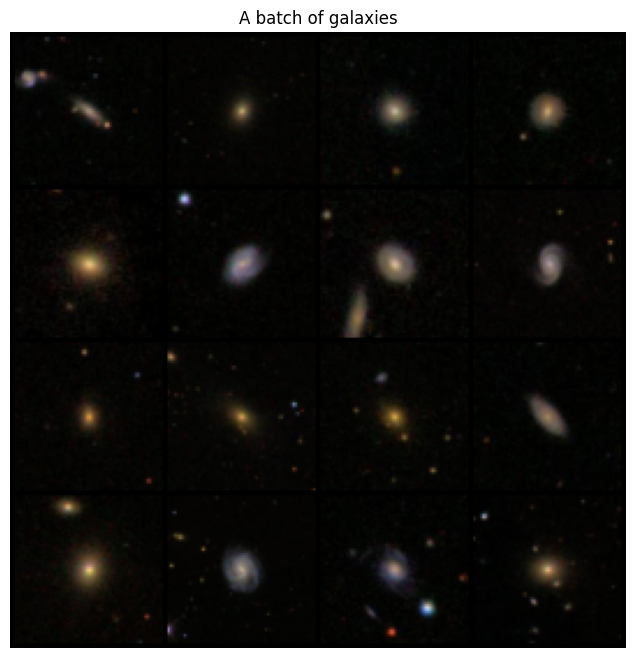

Labels: ['elliptical', 'elliptical', 'elliptical', 'spiral_barred', 'elliptical', 'spiral_barred', 'spiral_barred', 'spiral_barred', 'elliptical', 'elliptical', 'elliptical', 'spiral', 'elliptical', 'spiral_barred', 'spiral_barred', 'spiral']


In [ ]:
images_show = images * 0.5 + 0.5
grid = torchvision.utils.make_grid(images_show[:16], nrow=4)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title("A batch of galaxies")
plt.show()

print("Labels:", [dataset.classes[i] for i in labels[:16].tolist()])

## Stretch Goals *(optional)*

See [`09-project-task.md`](../09-project-task.md) for full descriptions:

1. Make a reproducible train/val split with `random_split` (seed it!).
2. Compute the **real** per-channel mean/std of the training set and use those in `Normalize`.
3. Plot several examples of each class side by side; guess which two will confuse a model.
4. Add `RandomHorizontalFlip` + `RandomRotation(180)` to a *train-only* transform and watch a galaxy flip/rotate.

In [ ]:
n_val = int(0.15 * len(dataset))
n_train = len(dataset) - n_val
train_subset, val_subset = random_split(
    dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42),
)
print(f"train: {len(train_subset)}  val: {len(val_subset)}")

train: 510  val: 90


In [ ]:
stat_ds = ImageFolder(
    root=DATA_ROOT,
    transform=transforms.Compose([transforms.Resize((64, 64)), transforms.ToTensor()]),
)
stat_loader = DataLoader(stat_ds, batch_size=64, shuffle=False, num_workers=2)

n_pixels = 0
channel_sum = torch.zeros(3)
channel_sq_sum = torch.zeros(3)
for imgs, _ in stat_loader:
    channel_sum += imgs.sum(dim=[0, 2, 3])
    channel_sq_sum += (imgs ** 2).sum(dim=[0, 2, 3])
    n_pixels += imgs.shape[0] * imgs.shape[2] * imgs.shape[3]

mean = channel_sum / n_pixels
std = (channel_sq_sum / n_pixels - mean ** 2).sqrt()
print("per-channel mean:", mean.tolist())
print("per-channel std :", std.tolist())

per-channel mean: [0.0449175089597702, 0.039617836475372314, 0.02938678488135338]
per-channel std : [0.08635631948709488, 0.0710938423871994, 0.06258634477853775]


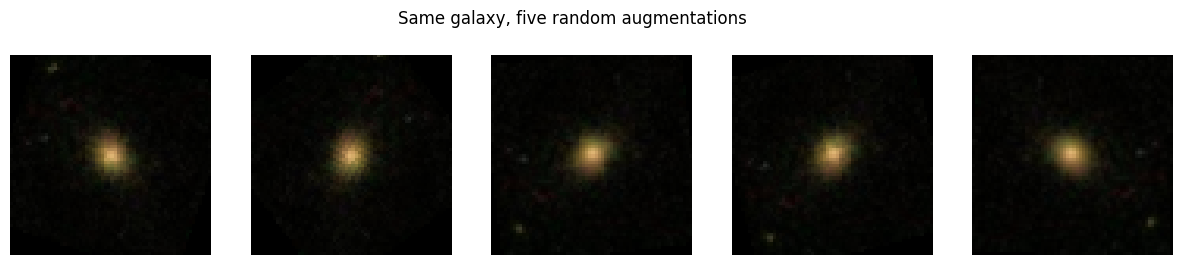

In [ ]:
aug = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(180),
    transforms.ToTensor(),
])

img_path, _ = dataset.samples[0]
from PIL import Image
pil_img = Image.open(img_path).convert("RGB")

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax in axes:
    ax.imshow(aug(pil_img).permute(1, 2, 0).numpy())
    ax.axis("off")
fig.suptitle("Same galaxy, five random augmentations")
plt.show()

## Reflection *(write 2–3 sentences each)*

Answer the prompts from [`09-project-task.md`](../09-project-task.md):

1. Most confusing part of setup / the data pipeline, and how you resolved it.
2. Pick one galaxy class and describe what a CNN must detect to recognise it.
3. After viewing real batches: which two classes will be hardest to tell apart, and why?
4. Why so much effort on the data pipeline *before* any model?

Answer 1: Got issue with using system files in colab, was a new thing for me, got help with an LLM to import kaggle.json file in this colab, and then use the data.

Answer 2: Say Spiral; disk with spiral arms, dark dust lanes, new stars forming with blue/pink dots,etc.

Answer 3: In my opinion Elliptical vs Lenticular (Face-on) because of smooth elliptical appearance for both, or very far away Spirals where distict arms are very faint and appear to be smooth bright dots instead like Elliptical.

Answer 4: These steps are necessary for the smooth implementation when we introduce any model to the picture.